In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1.
Firstly, I'll create a function to implement RK-2 so that I can pass multiple interval values. Then, I'll solve the equation numerically for different interval values. Lastly, to check the result for n=100 numerically, I'll compute the gradient using np.gradient and compute f(t,x) to compare the two.

In [2]:
def RK2(f, n, t_i=0, t_f=10, x_0=0):
    '''
    function that implements RK-2
    t_i is first t value
    t_f is final t value
    x_0 is initial value, in our case x(0)=0
    '''
    # discretize t
    h = (t_f - t_i) / (n - 1)
    t = np.linspace(t_i,t_f,n)

    # create x-grid
    x = np.zeros(n)
    x[0] = x_0

    # implement RK-2 method
    for i in range(n-1):
        k1 = f(t[i],x[i])
        k2 = f(t[i]+h/2,x[i]+k1*h/2)

        x[i+1] = x[i] + k2*h

    return t,x

Text(0, 0.5, 'x(t)')

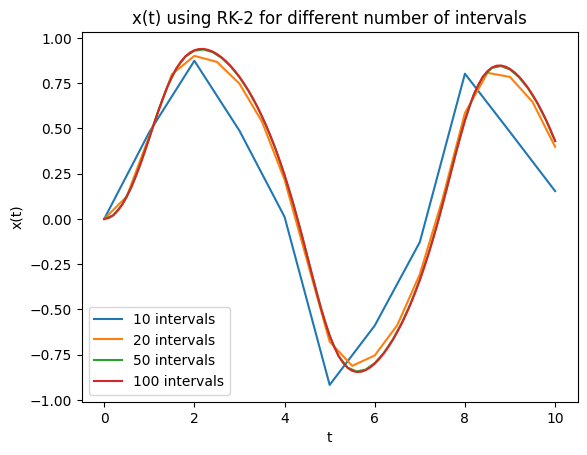

In [3]:
# create f: x'(t)=f(t,x)
def f(t,x):
    return -1*x**3 + np.sin(t)

t_10, x_10 = RK2(f, 11) # 10 intervals
t_20, x_20 = RK2(f, 21) # 20 intervals
t_50, x_50 = RK2(f, 51) # 50 intervals
t_100, x_100 = RK2(f, 101) # 100 intervals

plt.plot(t_10,x_10, label='10 intervals')
plt.plot(t_20,x_20, label='20 intervals')
plt.plot(t_50,x_50, label='50 intervals')
plt.plot(t_100,x_100, label='100 intervals')
plt.legend()
plt.title('x(t) using RK-2 for different number of intervals')
plt.xlabel('t')
plt.ylabel('x(t)')

Text(0, 0.5, "x'(t)")

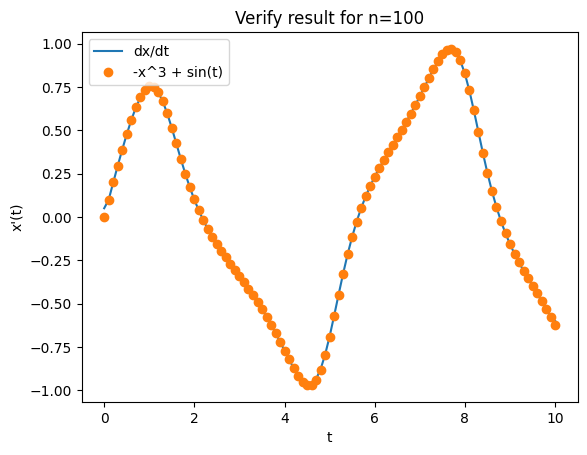

In [4]:
xprime = np.gradient(x_100,0.1) # h = (10-0)/100
xcheck = f(t_100,x_100)

plt.plot(t_100,xprime, label='dx/dt')
plt.plot(t_100,xcheck,'o', label=f'-x^3 + sin(t)')
plt.legend()
plt.title('Verify result for n=100')
plt.xlabel('t')
plt.ylabel("x'(t)")

# 2.
Firstly, I'll isolate the second derivative by moving every other term to the right:
\begin{equation}
    \frac{d^2x}{dt^2} = \left(\frac{dx}{dt}\right)^2-x-5
\end{equation}
Then I'll define $y=x'(t)$ and create the system of differential equations:
\begin{equation}
    x'(t) = y = f_x
\end{equation}
\begin{equation}
    y'(t) = y^2 -x-5 = f_y
\end{equation}
with the inital values $x(0)=1$ and $y(0)=0$ which I can then use RK-2 to solve simultaneously. 

Text(0, 0.5, 'x(t)')

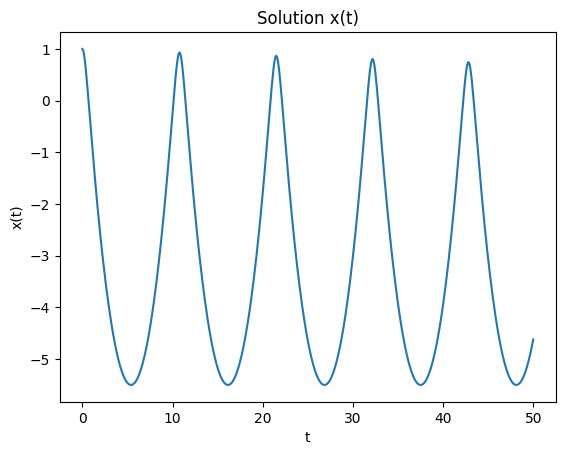

In [5]:
def f(r): # f is only a function of r
    x = r[0]
    y = r[1]
    
    f_x = y 
    f_y = y**2 - x -5

    return np.array([f_x, f_y])

# set t-grid from 0 to 50
t_i = 0
t_f = 50
n = 501 # split t into 500 intervals, each interval = 0.1
h = (t_f-t_i)/(n-1)

t = np.linspace(t_i,t_f,n)

# set x and y grids and their initial values
x = np.zeros(n)
y = np.zeros(n)
x[0] = 1 # x(0)=1
y[0] = 0 # x'(0)=0

r = np.array([x[0],y[0]])

# implement RK-2
for i in range(n-1):
    k1 = f(r)
    k2 = f(r+h*k1/2)

    r = r + h*k2

    x[i+1] = r[0]
    y[i+1] = r[1]

plt.plot(t,x)
plt.title('Solution x(t)')
plt.xlabel('t')
plt.ylabel('x(t)')

To check my solution, I'll use np.gradient twice on x and compare to $y^2 - x-5$.

Text(0, 0.5, "x''(t)")

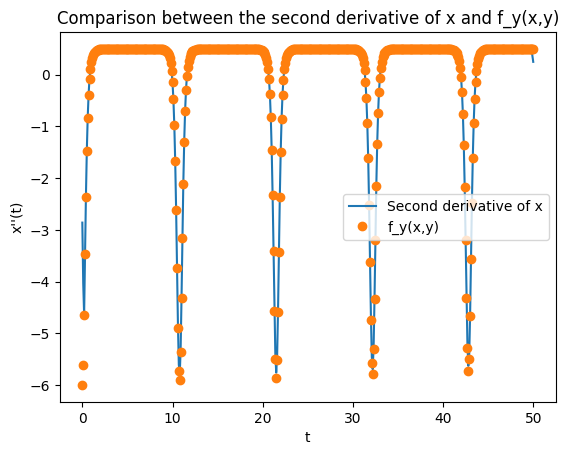

In [6]:
xprime = np.gradient(x,h)
xprimeprime = np.gradient(xprime,h)

xcheck = y**2 - x -5

plt.plot(t,xprimeprime, label='Second derivative of x')
plt.plot(t,xcheck,'o',label='f_y(x,y)')
plt.legend()
plt.title('Comparison between the second derivative of x and f_y(x,y)')
plt.xlabel('t')
plt.ylabel("x''(t)")

# 3.

In [7]:
def f3(r): # f is only a function of r
    # constants to be used in f_x and f_y
    alpha = 1
    beta = 0.5
    gamma = 0.5
    delta = 2
    
    x = r[0]
    y = r[1]

    f_x = alpha*x - beta*x*y
    f_y = gamma*x*y - delta*y

    return np.array([f_x,f_y])

Text(0, 0.5, 'Population')

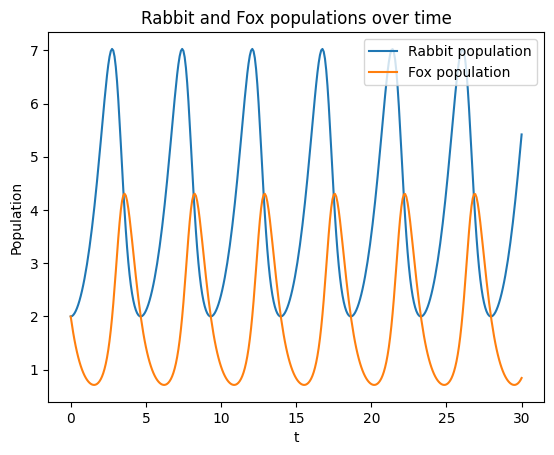

In [8]:
# create t grid for 0<t<30
t_i = 0
t_f = 30
n = 361
h = (t_f-t_i)/(n-1)

t = np.linspace(t_i,t_f,n)

# create r vector with initial conditions x(0)=y(0)=2
x = np.zeros(n)
y = np.zeros(n)
x[0] = 2
y[0] = 2

r = np.array([x[0],y[0]])

# Implement RK-4
for i in range(n-1):
    k1 = f3(r)
    k2 = f3(r+0.5*k1*h)
    k3 = f3(r+0.5*k2*h)
    k4 = f3(r+k3*h)

    r = r + h*(k1+2*k2+2*k3+k4)/6

    x[i+1] = r[0]
    y[i+1] = r[1]

plt.plot(t,x,label='Rabbit population')
plt.plot(t,y,label='Fox population')
plt.legend()
plt.title('Rabbit and Fox populations over time')
plt.xlabel('t')
plt.ylabel('Population')

# 4.

In [9]:
l = 0.1 # m
g = 9.81 # ms^-2
A = 0.02 # m

# def f(r,t) with extra omega parameter to set frequency of driver
def f4(r,t,omega):
    theta = r[0]
    tprime = r[1]

    f_theta = tprime
    f_tprime = (-g/l) * np.sin(theta) - (A*omega**2*np.cos(omega*t)/l) * np.sin(theta)

    return np.array([f_theta, f_tprime])

## a.

([<matplotlib.axis.XTick at 0x1f236e9dd10>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10')])

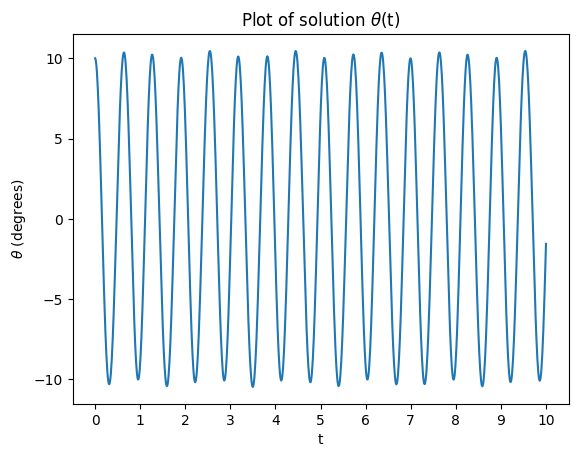

In [32]:
omega = 2 * np.pi # rad/s

# discretize t-grid
t_i = 0
t_f = 10
n = 1001
h = (t_f-t_i)/(n-1)

t = np.linspace(t_i,t_f,n)

# create theta and tprime grids and set initial values
theta = np.zeros(n)
tprime = np.zeros(n)

theta[0] = 10 * np.pi / 180 # convert 10 degrees to radians
tprime[0] = 0

r = np.array([theta[0],tprime[0]])

# implement RK-4
for i in range(n-1):
    k1 = f4(r,t[i],omega)
    k2 = f4(r+0.5*h*k1,t[i]+0.5*h,omega)
    k3 = f4(r+0.5*h*k2,t[i]+0.5*h,omega)
    k4 = f4(r+h*k3,t[i]+h,omega)

    r = r + h*(k1+2*k2+2*k3+k4)/6

    theta[i+1] = r[0]
    tprime[i+1] = r[1]

theta = theta * 180 / np.pi # covert theta to degrees for readibility

plt.plot(t,theta)
plt.title(r"Plot of solution $\theta$(t)")
plt.xlabel('t')
plt.ylabel(r"$\theta$ (degrees)")
xticks = np.arange(11)
plt.xticks(xticks)

# b.

Text(0, 0.5, '$\\theta$ (degrees)')

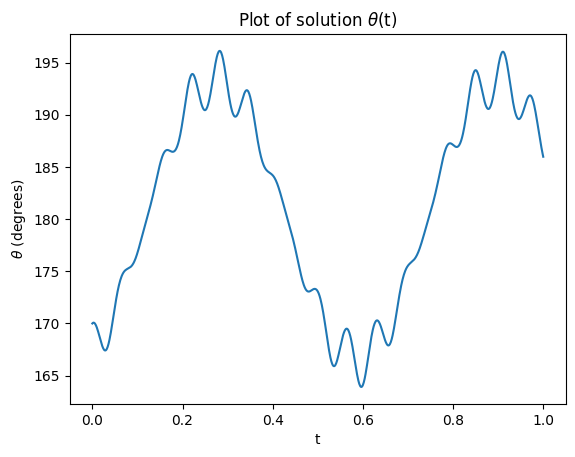

In [22]:
omega = 100 # rad/sec

# discretize t-grid
t_i = 0
t_f = 1
n = 1001
h = (t_f-t_i)/(n-1)

t = np.linspace(t_i,t_f,n)

# create theta and tprime grids and set initial values
theta = np.zeros(n)
tprime = np.zeros(n)

theta[0] = 170 * np.pi / 180 # convert 170 degrees to radians
tprime[0] = 1 # rad/sec

r = np.array([theta[0],tprime[0]])

# implement RK-4
for i in range(n-1):
    k1 = f4(r,t[i],omega)
    k2 = f4(r+0.5*h*k1,t[i]+0.5*h,omega)
    k3 = f4(r+0.5*h*k2,t[i]+0.5*h,omega)
    k4 = f4(r+h*k3,t[i]+h,omega)

    r = r + h*(k1+2*k2+2*k3+k4)/6

    theta[i+1] = r[0]
    tprime[i+1] = r[1]

theta = theta * 180 / np.pi # covert theta to degrees for readibility

plt.plot(t,theta)
plt.title(r"Plot of solution $\theta$(t)")
plt.xlabel('t')
plt.ylabel(r"$\theta$ (degrees)")